# Public Attention to Selected Boy Groups: A Python-Based Entertainment Marketing Analysis

## 1. Problem
This project compares public search attention across Seventeen, EXO, and Stray Kids over the past 12 months. The aim is to identify differences in online attention patterns and consider how these patterns may provide useful insights for entertainment marketing, campaign timing, and audience engagement.

## 2. Intended User / Audience
The intended users of this project include entertainment companies, marketing teams, and students who are interested in entertainment marketing and audience attention patterns in the music industry.

## 3. Data Source

This project uses Google Trends data to compare the online search interest of Seventeen, EXO, and Stray Kids. The dataset was accessed on 21 April 2026 from Google Trends Explore. The three groups were compared using the same settings to support a fair comparison.

Google Trends data are presented as a relative search-interest index scaled from 0 to 100 within the selected comparison setting. Therefore, the dataset reflects relative public attention rather than absolute search volume.

### Recorded data details
- Source: Google Trends Explore
- Access date: 21 April 2026
- Region: Worldwide
- Time range: Past 12 months
- Search type: Web Search
- Search terms: Seventeen, EXO, Stray Kids
- Data type: relative search-interest index (0–100)
- File used in this notebook: `data/google_trends.csv`

## 4. Data Loading

In [26]:
import pandas as pd

trends_df = pd.read_csv("data/google_trends.csv", skiprows=1)

trends_df.head()

,Week,Seventeen: (Worldwide),EXO: (Worldwide),Stray Kids: (Worldwide)
0,2025-04-20,44,34,44
1,2025-04-27,41,33,43
2,2025-05-04,39,35,42
3,2025-05-11,41,35,39
4,2025-05-18,49,35,43


In [35]:
trends_df.columns

Index(['Week', 'Seventeen', 'EXO', 'Stray_Kids'], dtype='object')

In [36]:
trends_df.shape

(53, 4)

Note: the dataset is first loaded with the original Google Trends column names. In later steps, the variable `trends_df` is cleaned and the columns are simplified to `Seventeen`, `EXO`, and `Stray_Kids`, so later reruns may display the simplified names.

## 5. Data Cleaning

The Google Trends dataset was cleaned in three steps. First, the first row containing the category information was skipped because it was not part of the actual data table. Second, the column names were simplified to make the dataset easier to read and analyse. Third, the `Week` column was converted into a datetime format. A missing-value check showed that the dataset contained no missing values.

In [37]:
trends_df = trends_df.rename(columns={
    "Week": "Week",
    "Seventeen: (Worldwide)": "Seventeen",
    "EXO: (Worldwide)": "EXO",
    "Stray Kids: (Worldwide)": "Stray_Kids"
})

trends_df["Week"] = pd.to_datetime(trends_df["Week"])

trends_df.head()

,Week,Seventeen,EXO,Stray_Kids
0,2025-04-20,44,34,44
1,2025-04-27,41,33,43
2,2025-05-04,39,35,42
3,2025-05-11,41,35,39
4,2025-05-18,49,35,43


In [38]:
trends_df.dtypes

Week          datetime64[ns]
Seventeen              int64
EXO                    int64
Stray_Kids             int64
dtype: object

In [39]:
trends_df.isna().sum()

Week          0
Seventeen     0
EXO           0
Stray_Kids    0
dtype: int64

## 6. Analysis

In [40]:
trends_df[["Seventeen", "EXO", "Stray_Kids"]].describe()

,Seventeen,EXO,Stray_Kids
count,53.000000,53.000000,53.000000
mean,40.886792,40.735849,64.641509
std,5.966768,6.367438,15.785941
min,33.000000,33.000000,39.000000
25%,36.000000,36.000000,53.000000
50%,40.000000,39.000000,61.000000
75%,44.000000,43.000000,75.000000
max,64.000000,58.000000,100.000000


The descriptive statistics show that Stray Kids had the highest average relative search-interest score during the selected period. Their standard deviation was also much higher than that of Seventeen and EXO, which suggests stronger fluctuations over time. By contrast, Seventeen and EXO had similar average levels of relative attention and relatively more stable search-interest patterns. These values should be interpreted as Google Trends index scores rather than absolute search volumes.

## 7. Outputs / Visualisations

### 7.1 Search Interest Over Time
This line chart shows how relative search interest changed week by week for Seventeen, EXO, and Stray Kids during the selected period.

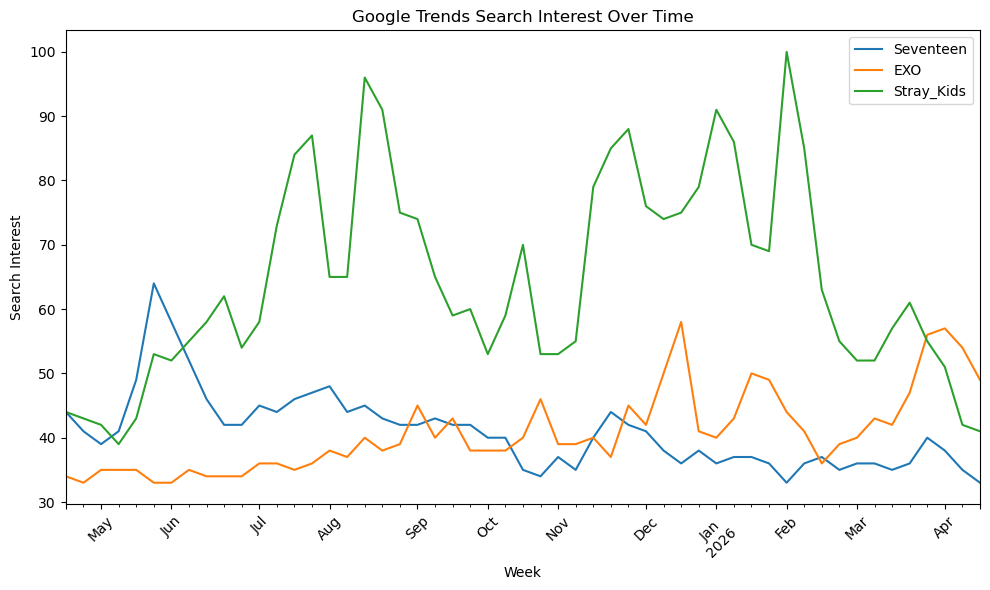

In [43]:
import matplotlib.pyplot as plt

trends_df.plot(x="Week", y=["Seventeen", "EXO", "Stray_Kids"], figsize=(10, 6))
plt.title("Google Trends Search Interest Over Time")
plt.xlabel("Week")
plt.ylabel("Search Interest")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 7.2 Average Search Interest by Group
This bar chart compares the average relative search interest of the three groups across the full selected period.

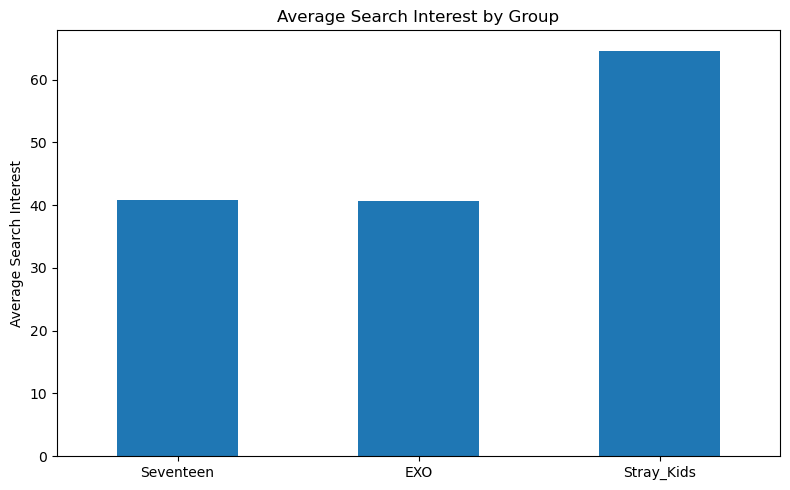

In [44]:
average_interest = trends_df[["Seventeen", "EXO", "Stray_Kids"]].mean()

average_interest.plot(kind="bar", figsize=(8, 5))
plt.title("Average Search Interest by Group")
plt.ylabel("Average Search Interest")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 7.3 Boxplot of Search Interest by Group
This boxplot compares the distribution of search interest for the three groups and helps show differences in variation over time

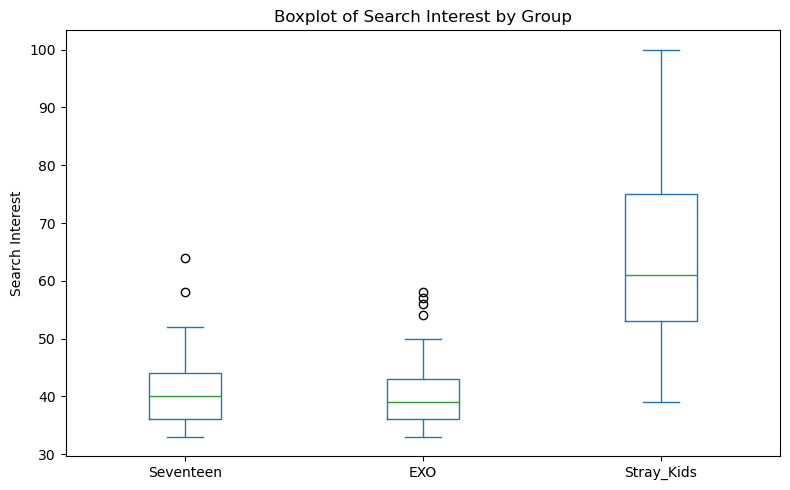

In [46]:
trends_df[["Seventeen", "EXO", "Stray_Kids"]].plot(kind="box", figsize=(8, 5))
plt.title("Boxplot of Search Interest by Group")
plt.ylabel("Search Interest")
plt.tight_layout()
plt.show()

The boxplot shows that Stray Kids had a higher overall distribution of search interest and a wider spread of values than Seventeen and EXO. This suggests that Stray Kids not only attracted higher relative attention, but also experienced stronger fluctuations over time.

### 7.4 Monthly Average Search Interest by Group
This chart summarises the weekly data at the monthly level and makes broader attention patterns easier to compare.

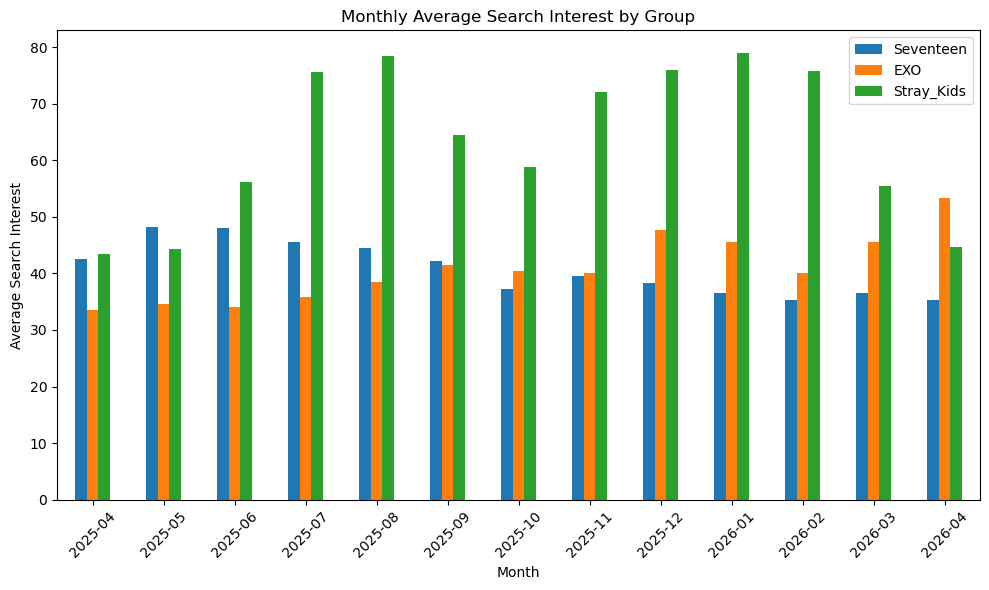

In [48]:
monthly_avg = trends_df.set_index("Week")[["Seventeen", "EXO", "Stray_Kids"]].resample("ME").mean()
monthly_avg.index = monthly_avg.index.strftime("%Y-%m")

monthly_avg.plot(kind="bar", figsize=(10, 6))
plt.title("Monthly Average Search Interest by Group")
plt.xlabel("Month")
plt.ylabel("Average Search Interest")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The monthly average chart shows that Stray Kids remained above the other two groups in most months, which suggests stronger average public attention over a broader time scale. Seventeen was relatively steady, while EXO showed more noticeable growth in the later months of the selected period. This chart is useful because it reduces weekly noise and makes broader changes in attention easier to compare.

### 7.5 4-Week Rolling Average of Search Interest
This line chart smooths short-term fluctuations and highlights the broader trend more clearly across the three groups.

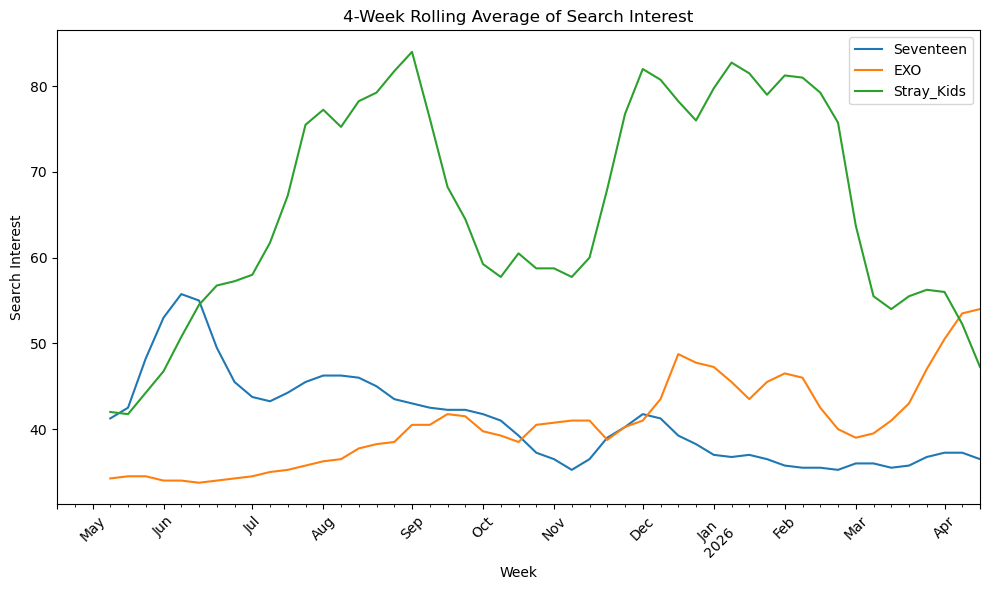

In [49]:
rolling_avg = trends_df.set_index("Week")[["Seventeen", "EXO", "Stray_Kids"]].rolling(window=4).mean()

rolling_avg.plot(figsize=(10, 6))
plt.title("4-Week Rolling Average of Search Interest")
plt.xlabel("Week")
plt.ylabel("Search Interest")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The rolling-average chart makes the longer-term trend easier to interpret by smoothing sharp weekly spikes. It confirms that Stray Kids generally maintained a higher level of attention, while Seventeen and EXO followed lower and more stable patterns for much of the period.

### 7.6 Standard Deviation of Search Interest by Group
This bar chart compares the standard deviation of search interest for the three groups. It helps show which group experienced stronger fluctuations over time.

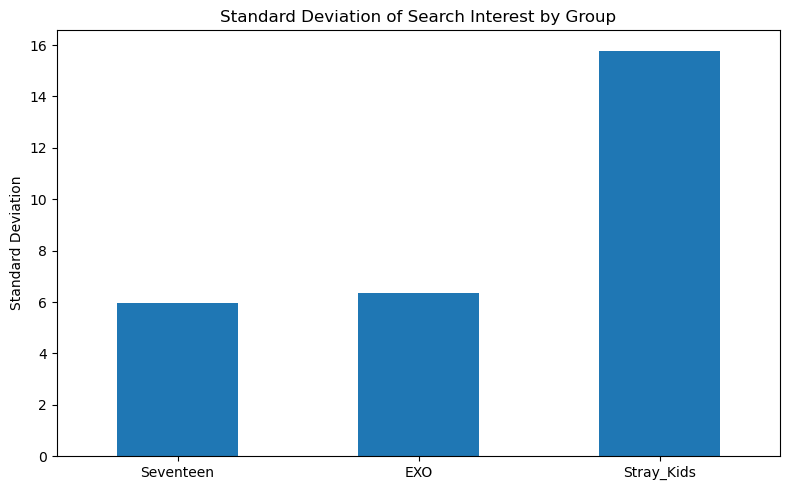

In [50]:
std_interest = trends_df[["Seventeen", "EXO", "Stray_Kids"]].std()

std_interest.plot(kind="bar", figsize=(8, 5))
plt.title("Standard Deviation of Search Interest by Group")
plt.ylabel("Standard Deviation")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

This chart provides a direct numerical comparison of volatility. The higher standard deviation of Stray Kids supports the earlier visual evidence from the line chart and boxplot, suggesting that this group experienced stronger fluctuations in public search attention during the selected period.

## 8. Key Findings

Overall, the results suggest that Stray Kids attracted the highest level of relative search interest during the selected period. This pattern is visible not only in the original weekly line chart, but also in the average-interest bar chart, the boxplot, the monthly average chart, the rolling-average chart, and the standard-deviation comparison. Taken together, these outputs suggest that Stray Kids generally maintained stronger public search attention than Seventeen and EXO.

At the same time, the results also show that Stray Kids had the greatest variation in attention over time. The boxplot and the standard-deviation chart both indicate a wider spread and stronger fluctuations, which means that this group experienced more noticeable spikes in public search interest. By contrast, Seventeen and EXO showed lower and more stable relative attention levels for much of the selected period.

The comparison between Seventeen and EXO is more balanced. Their overall average levels of search interest were relatively similar, although EXO showed some stronger increases in the later part of the period. The monthly chart and rolling-average chart help show that these differences were not limited to only one or two isolated weeks.

From a marketing perspective, these findings suggest that different groups may generate different attention patterns. Some may attract stronger but less stable spikes in interest, while others may maintain steadier public attention over time. This may provide simple insights for entertainment companies and marketing teams when thinking about promotional timing, campaign planning, and audience engagement.

## 9. Limitations

This project has several limitations. First, it focuses on only three selected boy groups, so the findings cannot be used to represent the whole entertainment market. The groups were chosen partly to keep the comparison clearer and more balanced, but this also means the scope of the analysis is limited.

Second, the project uses only Google Trends data. These values are relative search-interest index scores rather than absolute search volumes, so they reflect relative public attention rather than full popularity, fan loyalty, or commercial performance. As a result, the findings should be interpreted carefully and should not be treated as direct evidence of sales, revenue, or overall market success.

Third, the analysis does not include event-level information such as comebacks, concerts, scandals, or major news coverage. This means the notebook can identify spikes and broader patterns, but it cannot fully explain the exact reason behind each change in search interest.

Finally, the analysis covers only one selected time period and one search platform setting. A longer time range, additional keywords, or other data sources could provide a more complete picture in future work.